Loading dataset from local path: C:\CE\CE-7\GitHub\AI LAB\AI LAB 5\WA_Fn-UseC_-Telco-Customer-Churn.csv

--- Part 1: Dataset Preview (First 5 Rows) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


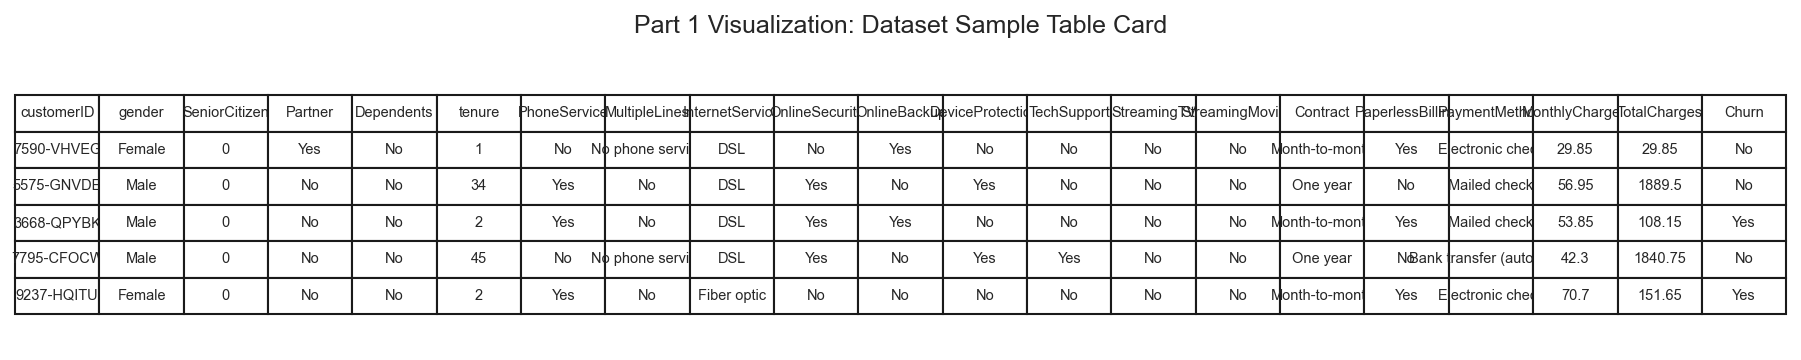

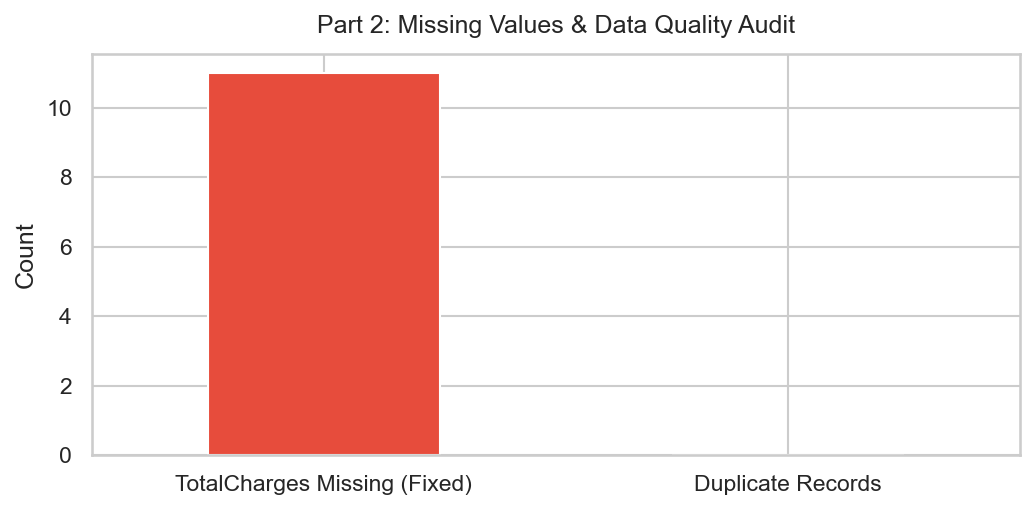


--- Part 3: Numerical Features Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80


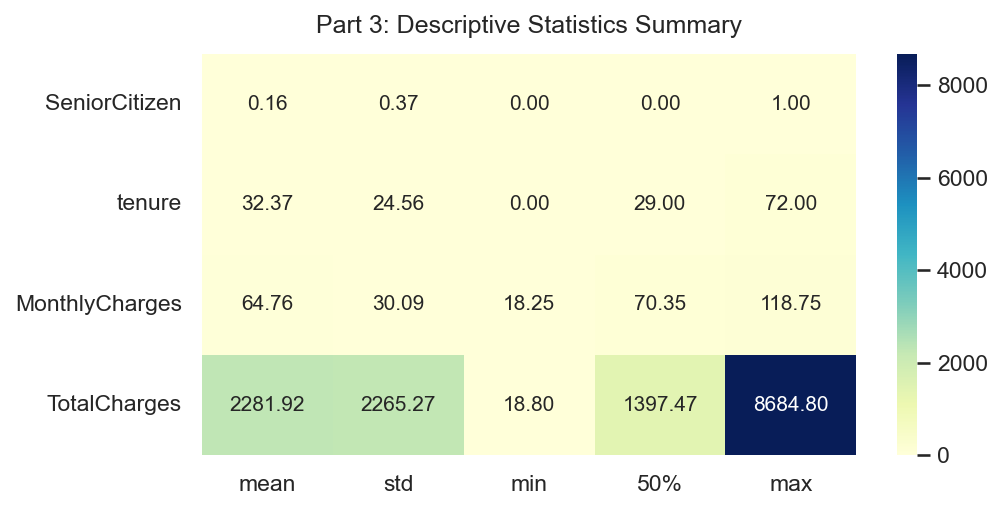

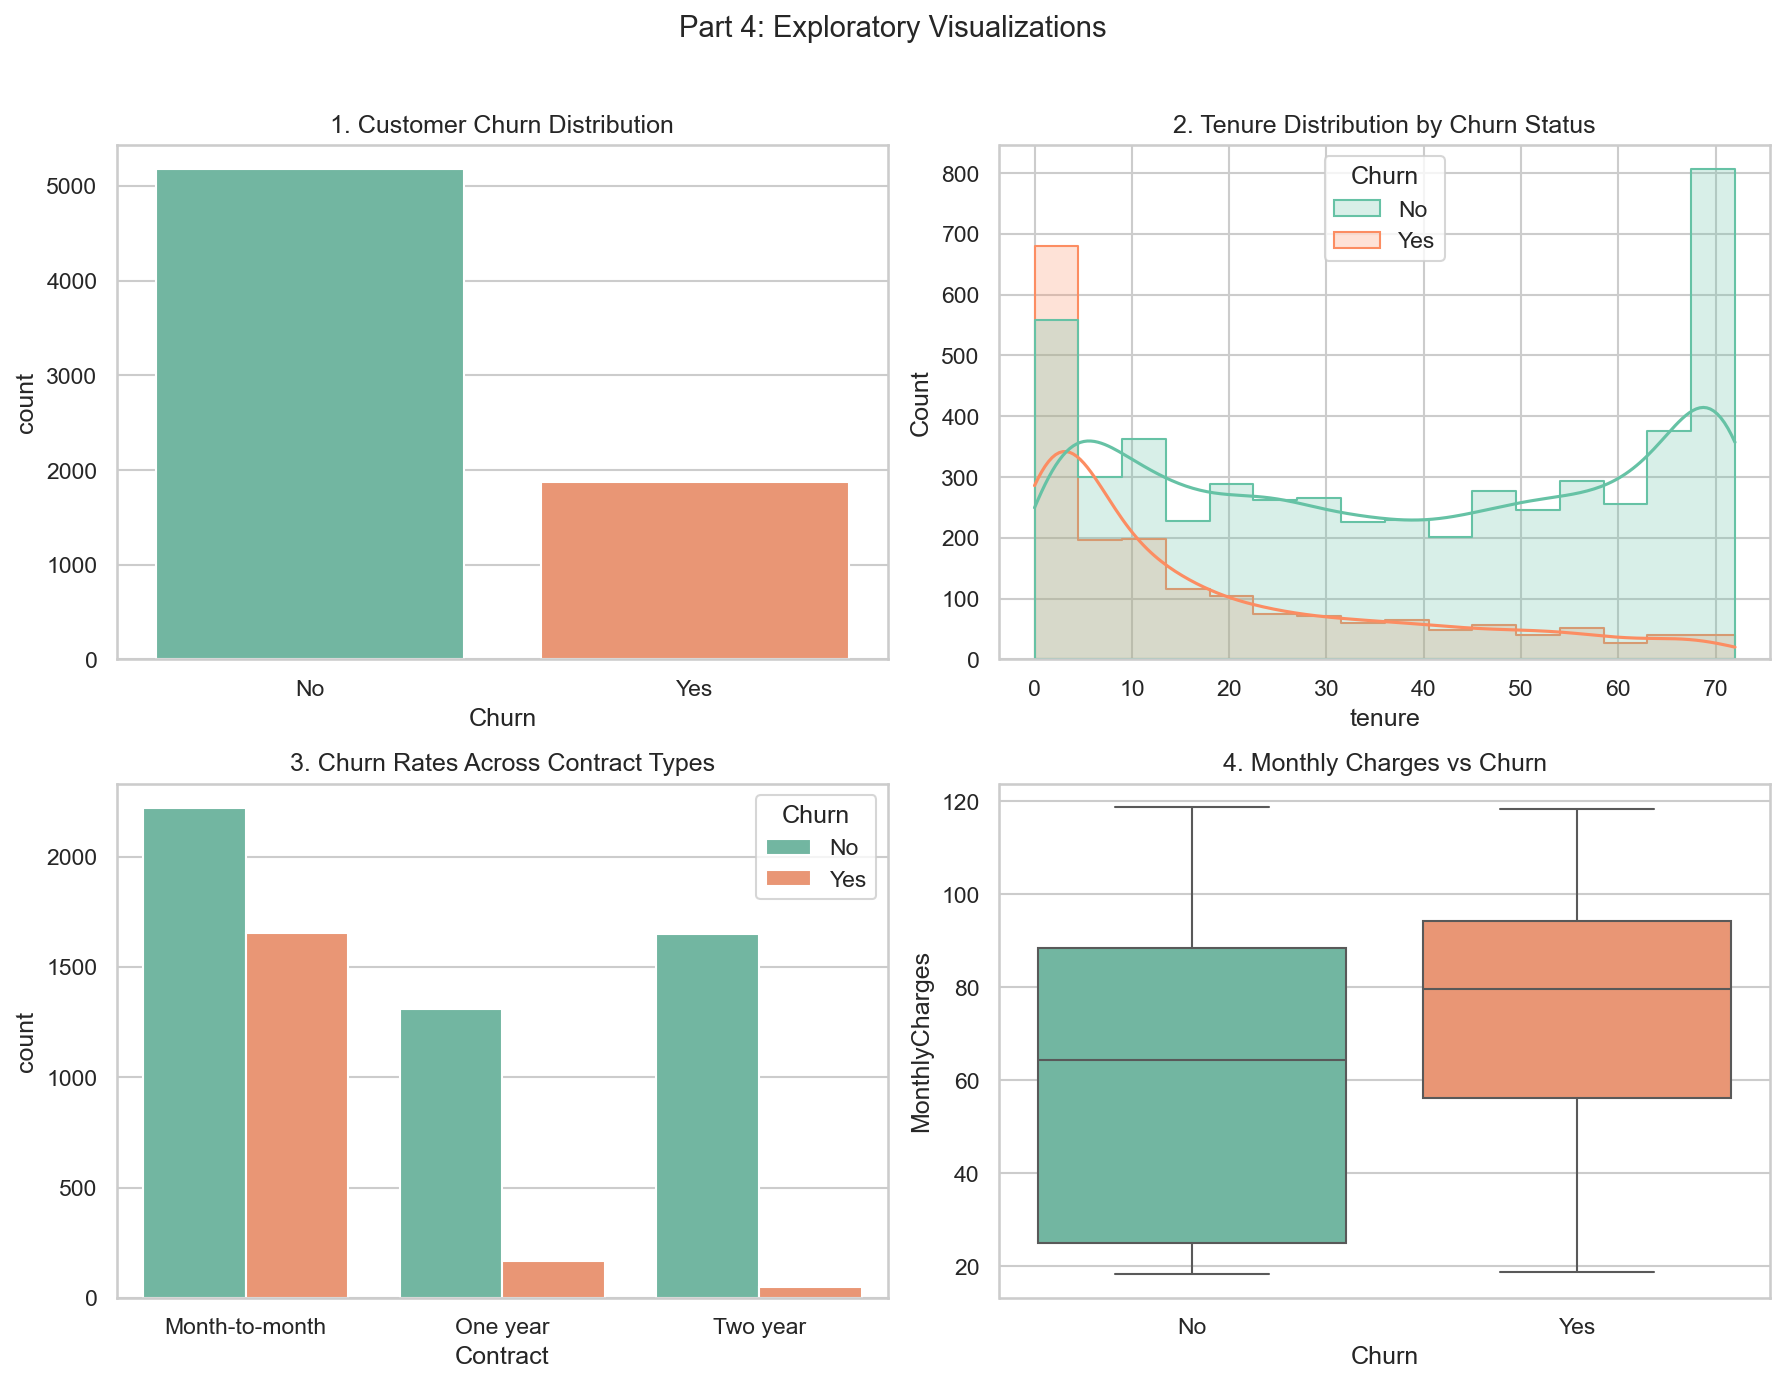

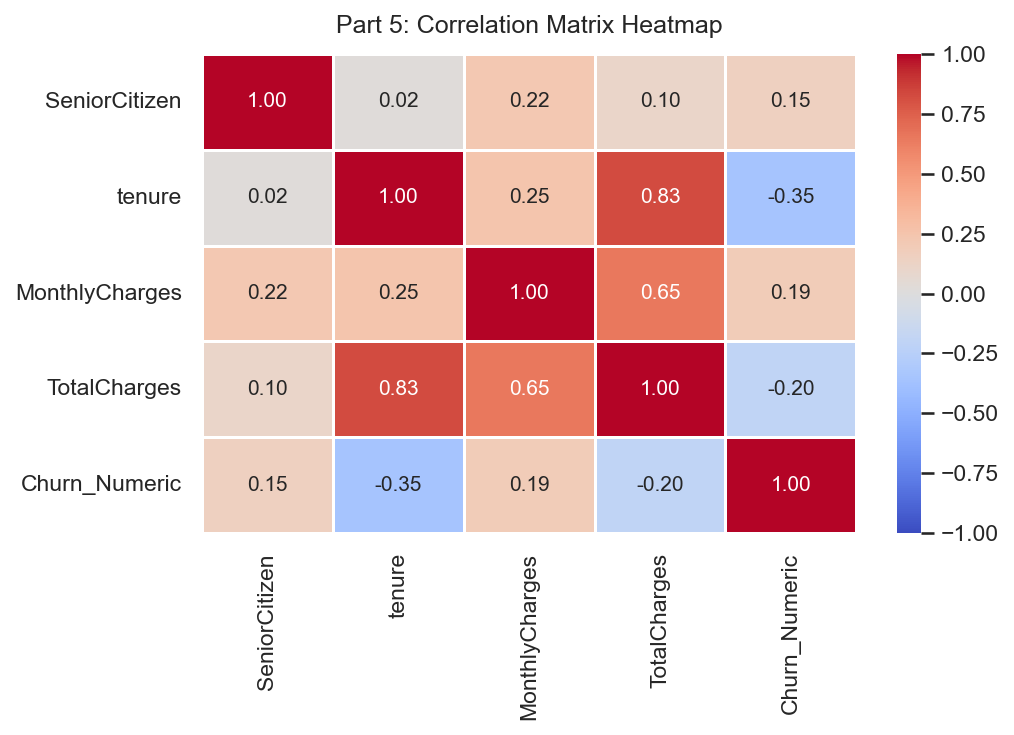

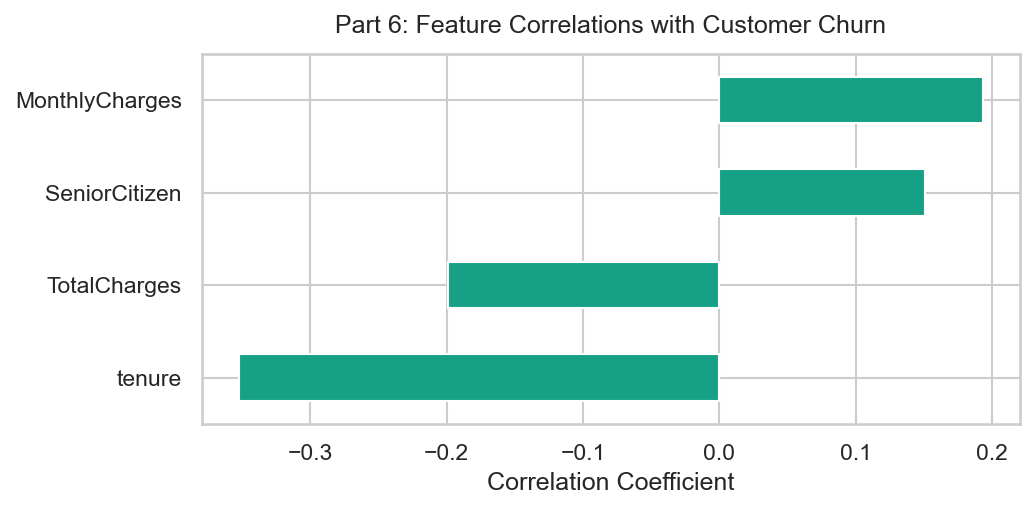

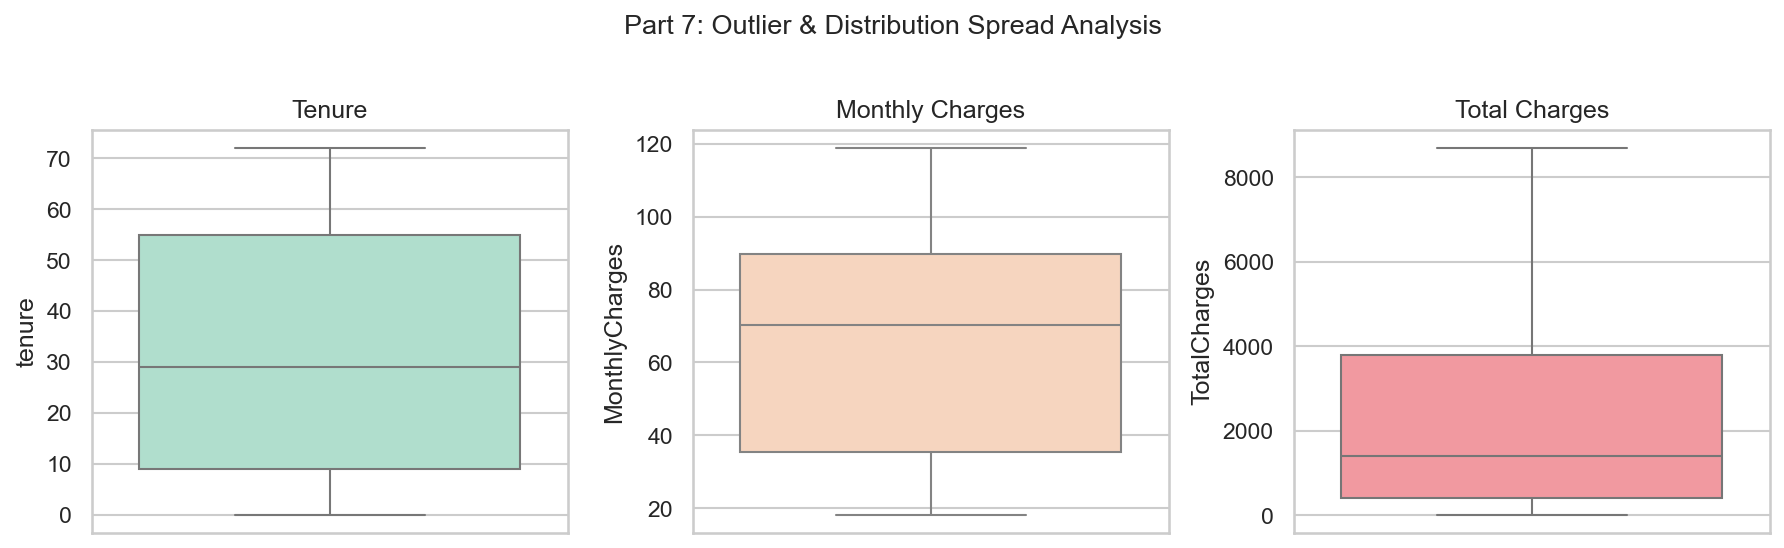


--- Part 8: Selected Features for Machine Learning Models ---


,Feature,Type,Churn Impact Significance
0,tenure,Numerical,High
1,Contract,Categorical,Very High
2,MonthlyCharges,Numerical,High
3,TotalCharges,Numerical,Moderate
4,InternetService,Categorical,High
5,TechSupport,Categorical,High
6,PaymentMethod,Categorical,Moderate


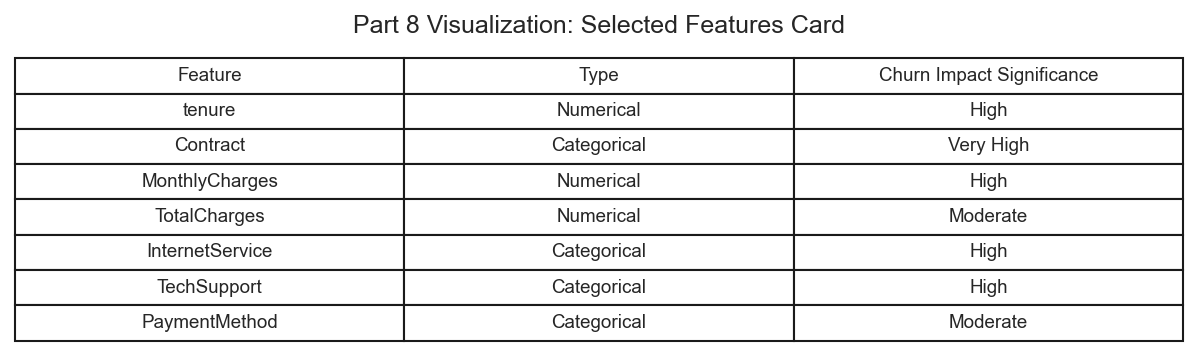


--- Part 9: Model Suitability Justification ---


,Model,Key Strengths for Churn Prediction
0,Logistic Regression,"Linear baseline, provides odds ratios/probabil..."
1,Random Forest,"Handles non-linear relationships, robust to ou..."


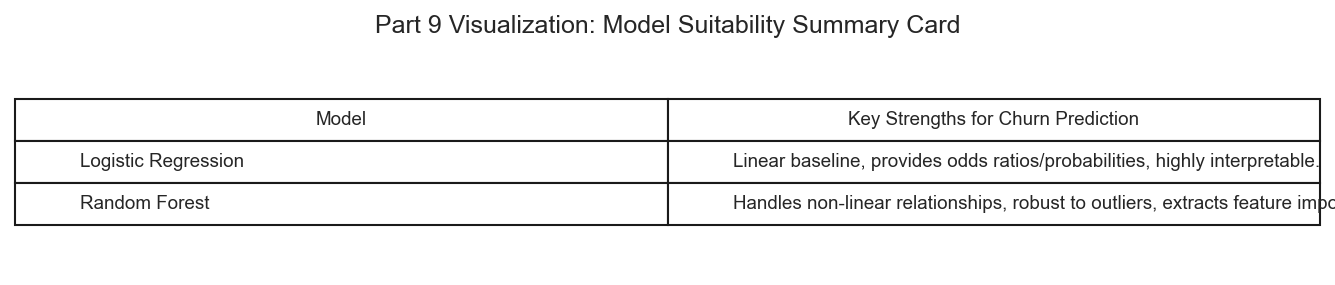


--- Model Training & Confusion Matrix Evaluation ---


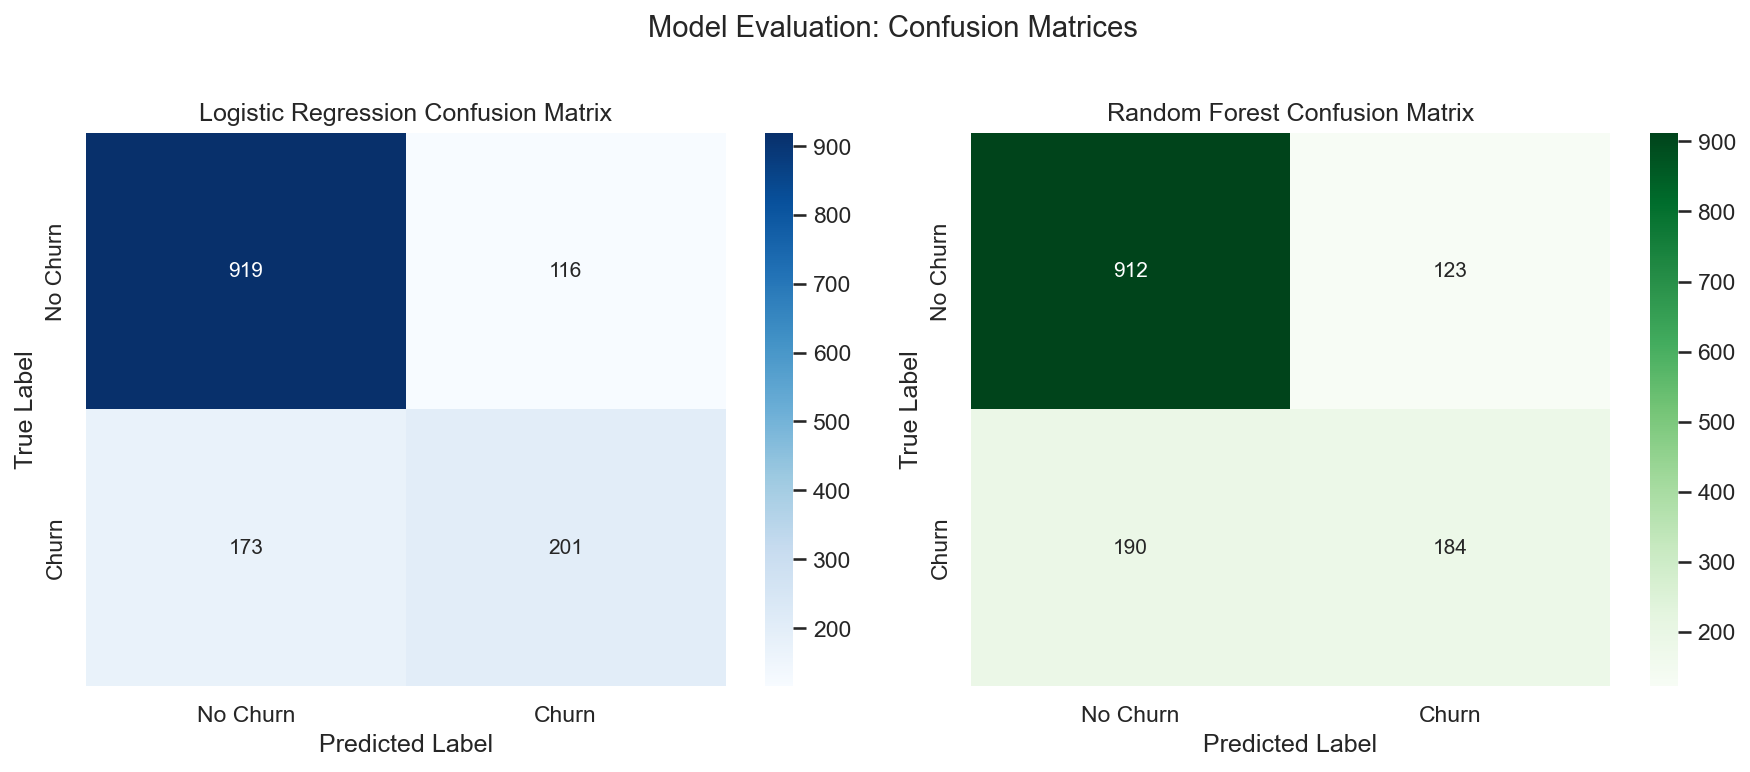

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [4]:
# ==============================================================================
# IMPORTS & SETUP
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries for Confusion Matrix & Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Suppress warnings
warnings.filterwarnings('ignore')

# Set high-DPI for crisp, sharp charts in Jupyter
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10


# ==============================================================================
# TASK 1: LOAD THE TELCO CUSTOMER CHURN DATASET
# ==============================================================================
dataset_dir = r"C:\CE\CE-7\GitHub\AI LAB\AI LAB 5"

csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in specified directory: {dataset_dir}")

full_path = os.path.join(dataset_dir, csv_files[0])
print(f"Loading dataset from local path: {full_path}")

df = pd.read_csv(full_path)

# Sharp, clear HTML table output for Jupyter
print("\n--- Part 1: Dataset Preview (First 5 Rows) ---")
display(df.head())

# ADDED VISUALIZATION: Graphical Table Card for Part 1
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')
ax.axis('tight')
tbl = ax.table(cellText=df.head(5).values, colLabels=df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1.2, 1.5)
plt.title("Part 1 Visualization: Dataset Sample Table Card", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 2: ANALYZE DATASET STRUCTURE, TYPES, MISSING VALUES & DUPLICATES
# ==============================================================================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

missing_before = df['TotalCharges'].isnull().sum()
if missing_before > 0:
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

duplicates_count = df.duplicated().sum()

# Plot Missing Values Audit Chart
fig, ax = plt.subplots(figsize=(7, 3.5))
missing_counts = pd.Series({
    'TotalCharges Missing (Fixed)': missing_before,
    'Duplicate Records': duplicates_count
})

missing_counts.plot(kind='bar', color=['#e74c3c', '#3498db'], ax=ax)
plt.title("Part 2: Missing Values & Data Quality Audit", fontsize=12, pad=10)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 3: PERFORM DESCRIPTIVE STATISTICAL ANALYSIS
# ==============================================================================
print("\n--- Part 3: Numerical Features Descriptive Statistics ---")
display(df.describe().T)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(df.describe().T[['mean', 'std', 'min', '50%', 'max']], annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
plt.title("Part 3: Descriptive Statistics Summary", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 4: CREATE AT LEAST FOUR RELEVANT VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Viz 1: Churn Class Distribution
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title("1. Customer Churn Distribution")

# Viz 2: Tenure Distribution by Churn Status
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element="step", palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title("2. Tenure Distribution by Churn Status")

# Viz 3: Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title("3. Churn Rates Across Contract Types")

# Viz 4: Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title("4. Monthly Charges vs Churn")

plt.suptitle("Part 4: Exploratory Visualizations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 5: GENERATE A CORRELATION MATRIX AND HEATMAP
# ==============================================================================
df_corr = df.copy()
df_corr['Churn_Numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Part 5: Correlation Matrix Heatmap", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 6: IDENTIFY IMPORTANT FEATURES RELATED TO CHURN
# ==============================================================================
churn_corr = corr_matrix['Churn_Numeric'].drop('Churn_Numeric').sort_values()

plt.figure(figsize=(7, 3.5))
churn_corr.plot(kind='barh', color='#16a085')
plt.title("Part 6: Feature Correlations with Customer Churn", fontsize=12, pad=10)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 7: IDENTIFY POSSIBLE OUTLIERS AND UNUSUAL OBSERVATIONS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.boxplot(y=df['tenure'], ax=axes[0], color='#a8e6cf').set_title("Tenure")
sns.boxplot(y=df['MonthlyCharges'], ax=axes[1], color='#ffd3b6').set_title("Monthly Charges")
sns.boxplot(y=df['TotalCharges'], ax=axes[2], color='#ff8b94').set_title("Total Charges")

plt.suptitle("Part 7: Outlier & Distribution Spread Analysis", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 8: SELECT RELEVANT FEATURES FOR LOGISTIC REGRESSION & RANDOM FOREST
# ==============================================================================
selected_features = {
    'Feature': ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'InternetService', 'TechSupport', 'PaymentMethod'],
    'Type': ['Numerical', 'Categorical', 'Numerical', 'Numerical', 'Categorical', 'Categorical', 'Categorical'],
    'Churn Impact Significance': ['High', 'Very High', 'High', 'Moderate', 'High', 'High', 'Moderate']
}
feat_df = pd.DataFrame(selected_features)

print("\n--- Part 8: Selected Features for Machine Learning Models ---")
display(feat_df)

# ADDED VISUALIZATION: Graphical Table Card for Part 8
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
ax.axis('tight')
tbl = ax.table(cellText=feat_df.values, colLabels=feat_df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.4)
plt.title("Part 8 Visualization: Selected Features Card", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 9: EXPLAIN MODEL SUITABILITY (LOGISTIC REGRESSION & RANDOM FOREST)
# ==============================================================================
model_reasons = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Key Strengths for Churn Prediction': [
        'Linear baseline, provides odds ratios/probabilities, highly interpretable.',
        'Handles non-linear relationships, robust to outliers, extracts feature importance.'
    ]
}
model_df = pd.DataFrame(model_reasons)

print("\n--- Part 9: Model Suitability Justification ---")
display(model_df)

# ADDED VISUALIZATION: Graphical Table Card for Part 9
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')
ax.axis('tight')
tbl = ax.table(cellText=model_df.values, colLabels=model_df.columns, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
plt.title("Part 9 Visualization: Model Suitability Summary Card", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


# ==============================================================================
# ADDED SECTION: MODEL TRAINING & CONFUSION MATRIX VISUALIZATION
# ==============================================================================
print("\n--- Model Training & Confusion Matrix Evaluation ---")

# 1. Feature Preprocessing (Encode Categorical Variables & Prepare Features)
feature_cols = ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'InternetService', 'TechSupport', 'PaymentMethod']
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 4. Generate Confusion Matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 5. Visualizations: Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix 1: Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title("Logistic Regression Confusion Matrix", fontsize=12)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Confusion Matrix 2: Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title("Random Forest Confusion Matrix", fontsize=12)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Model Evaluation: Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 6. Output Classification Reports
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))